<a href="https://colab.research.google.com/github/Nahom32/Credit-Score-Modelling/blob/main/notebooks/Credit_Score_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!pip install kagglehub

In [3]:
import kagglehub
path = kagglehub.dataset_download("cs49adityarajsharma/credit-scoring-data")

100%|██████████| 1.12M/1.12M [00:00<00:00, 1.63MB/s]

Extracting files...


In [4]:
import os

os.listdir(path)


['credit_scoring.csv',
 'P_13 - Project(Credit - Scroing using K_Means) (1).ipynb']

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [6]:
dataset = pd.read_csv(f"{path}/credit_scoring.csv")

In [7]:
dataset.describe()

,Age,Credit Utilization Ratio,Payment History,Number of Credit Accounts,Loan Amount,Interest Rate,Loan Term
count,1000.000000,1000.000000,1000.000000,1000.000000,1.000000e+03,1000.000000,1000.000000
mean,42.702000,0.509950,1452.814000,5.580000,2.471401e+06,10.686600,37.128000
std,13.266771,0.291057,827.934146,2.933634,1.387047e+06,5.479058,17.436274
min,20.000000,0.000000,0.000000,1.000000,1.080000e+05,1.010000,12.000000
25%,31.000000,0.250000,763.750000,3.000000,1.298000e+06,6.022500,24.000000
50%,42.000000,0.530000,1428.000000,6.000000,2.437500e+06,10.705000,36.000000
75%,54.000000,0.750000,2142.000000,8.000000,3.653250e+06,15.440000,48.000000
max,65.000000,1.000000,2857.000000,10.000000,4.996000e+06,19.990000,60.000000


In [8]:

print(dataset.head())
print(dataset.shape)

   Age  Gender Marital Status Education Level Employment Status  \
0   60    Male        Married          Master          Employed   
1   25    Male        Married     High School        Unemployed   
2   30  Female         Single          Master          Employed   
3   58  Female        Married             PhD        Unemployed   
4   32    Male        Married        Bachelor     Self-Employed   

   Credit Utilization Ratio  Payment History  Number of Credit Accounts  \
0                      0.22           2685.0                          2   
1                      0.20           2371.0                          9   
2                      0.22           2771.0                          6   
3                      0.12           1371.0                          2   
4                      0.99            828.0                          2   

   Loan Amount  Interest Rate  Loan Term   Type of Loan  
0      4675000           2.65         48  Personal Loan  
1      3619000           5.19 

In [9]:
missing_values = dataset.isnull().sum()
print("Missing values per column:\n", missing_values)

Missing values per column:
 Age                          0
Gender                       0
Marital Status               0
Education Level              0
Employment Status            0
Credit Utilization Ratio     0
Payment History              0
Number of Credit Accounts    0
Loan Amount                  0
Interest Rate                0
Loan Term                    0
Type of Loan                 0
dtype: int64


In [10]:
print(dataset.info())
# If needed, convert types (e.g., if any are object)
# dataset['Age'] = dataset['Age'].astype(float)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Age                        1000 non-null   int64  
 1   Gender                     1000 non-null   object 
 2   Marital Status             1000 non-null   object 
 3   Education Level            1000 non-null   object 
 4   Employment Status          1000 non-null   object 
 5   Credit Utilization Ratio   1000 non-null   float64
 6   Payment History            1000 non-null   float64
 7   Number of Credit Accounts  1000 non-null   int64  
 8   Loan Amount                1000 non-null   int64  
 9   Interest Rate              1000 non-null   float64
 10  Loan Term                  1000 non-null   int64  
 11  Type of Loan               1000 non-null   object 
dtypes: float64(3), int64(4), object(5)
memory usage: 93.9+ KB
None


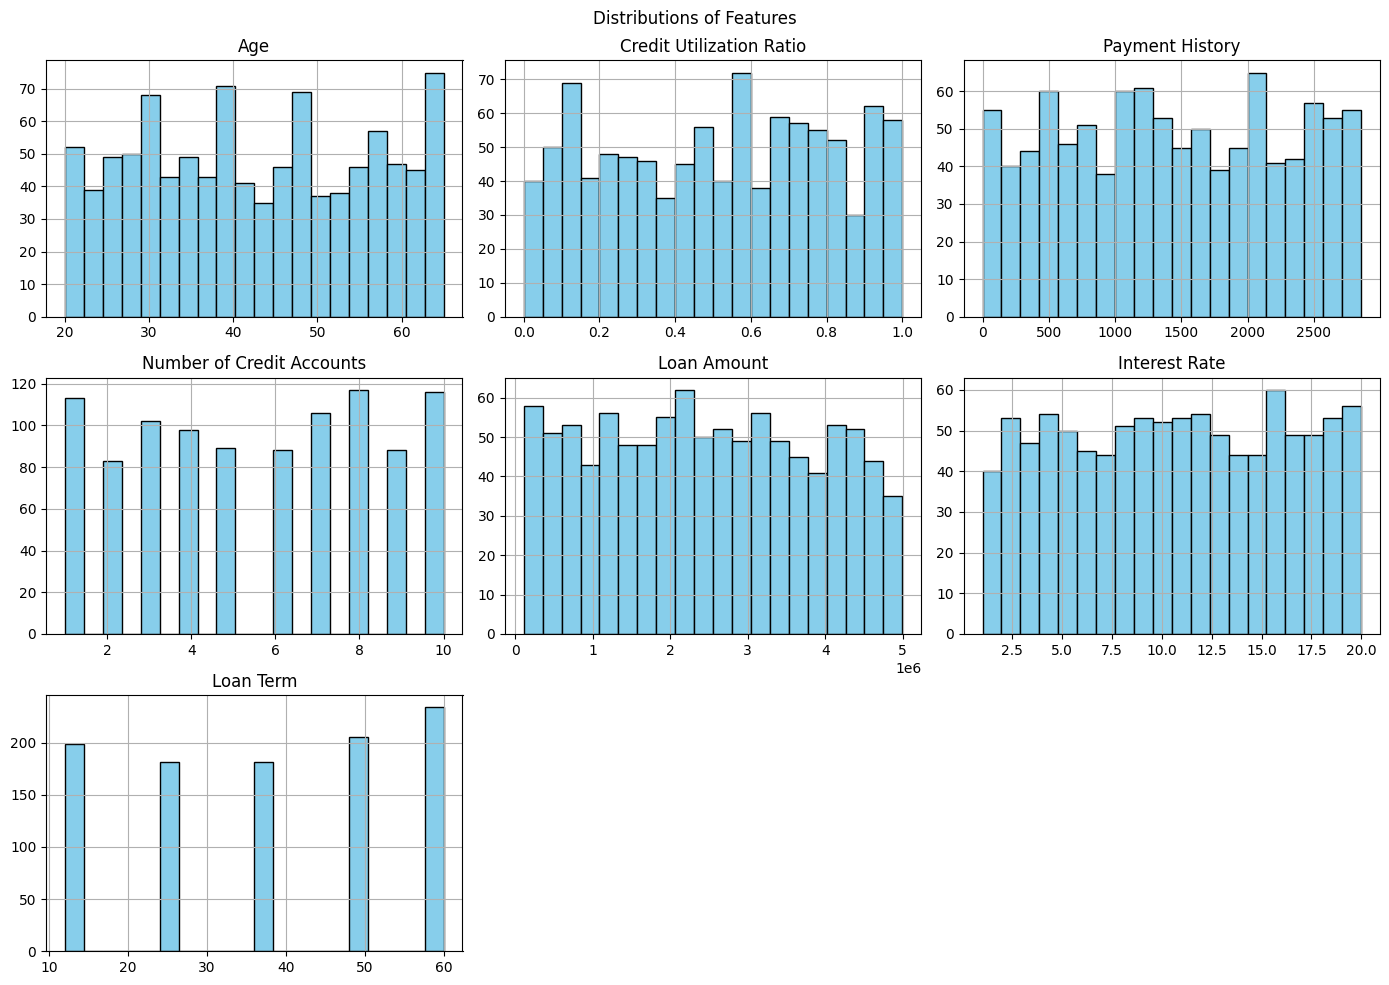

In [11]:
# Histograms for all columns
dataset.hist(bins=20, figsize=(14, 10), color='skyblue', edgecolor='black')
plt.suptitle('Distributions of Features')
plt.tight_layout()
plt.show()

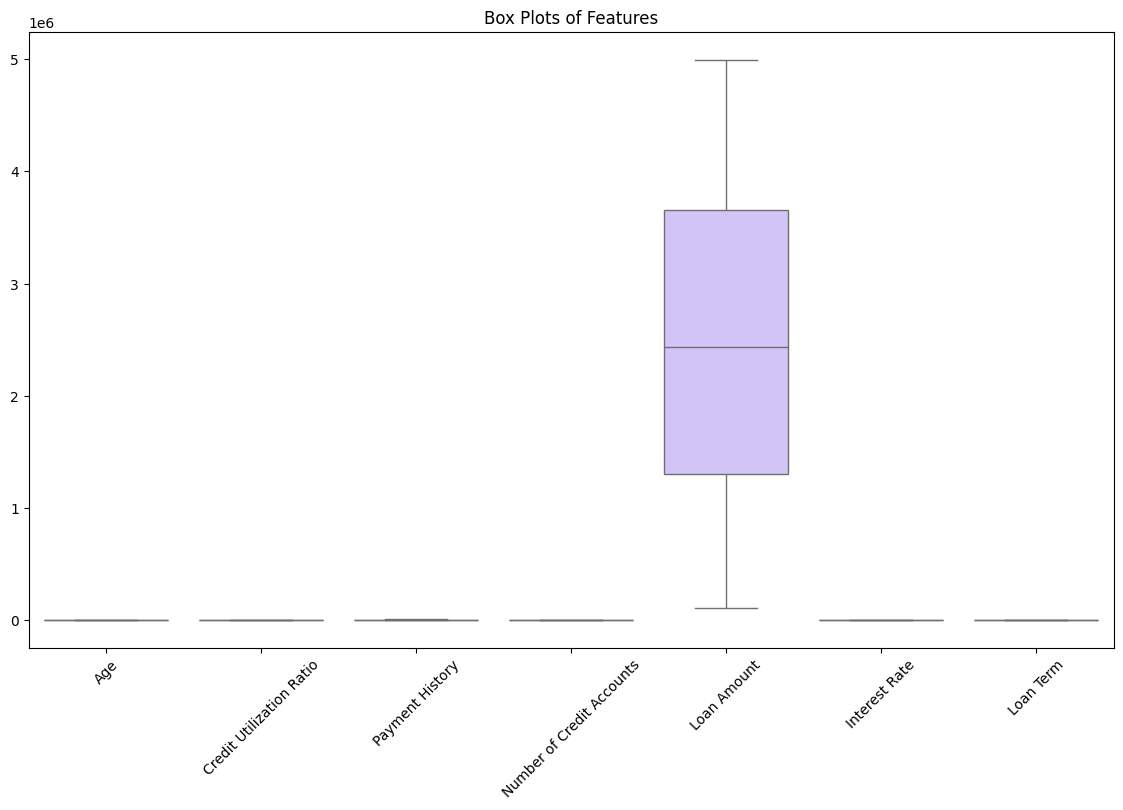

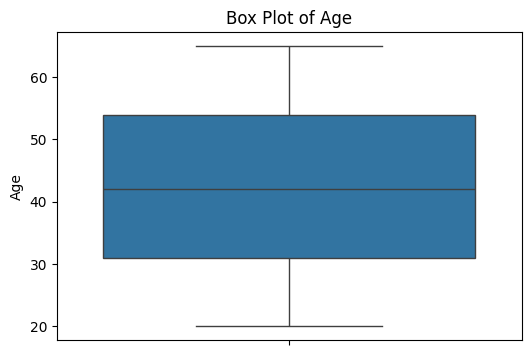

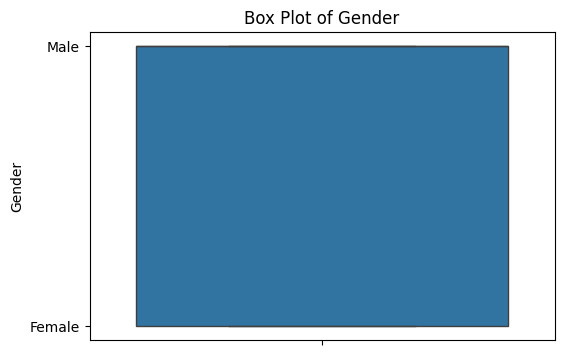

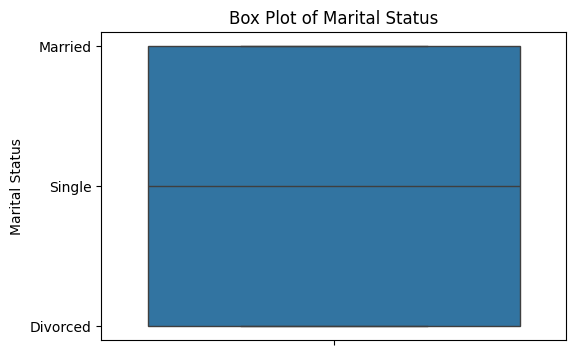

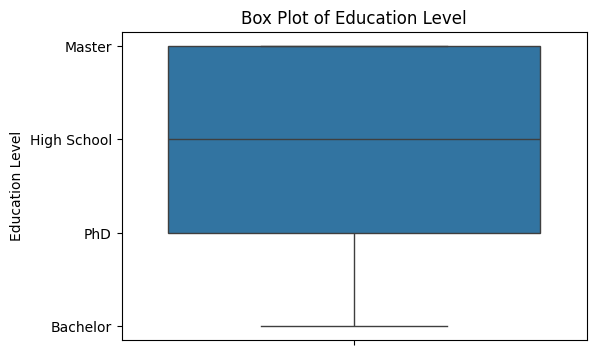

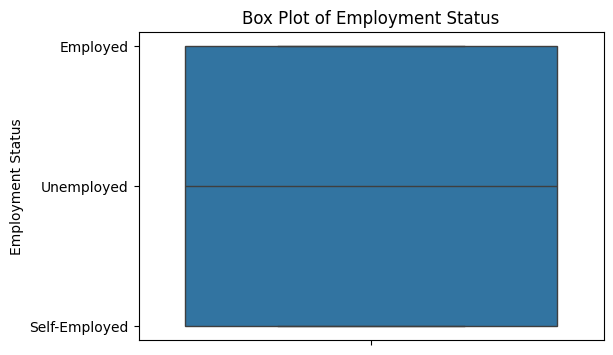

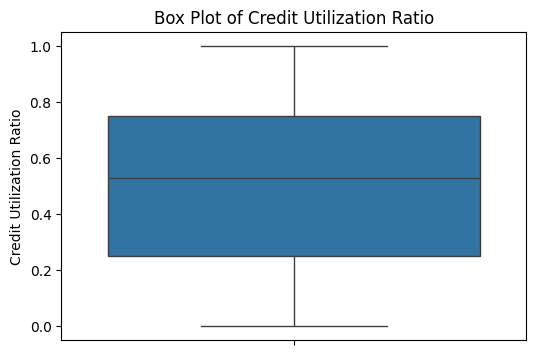

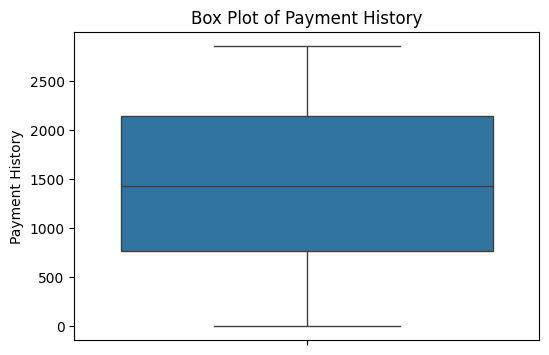

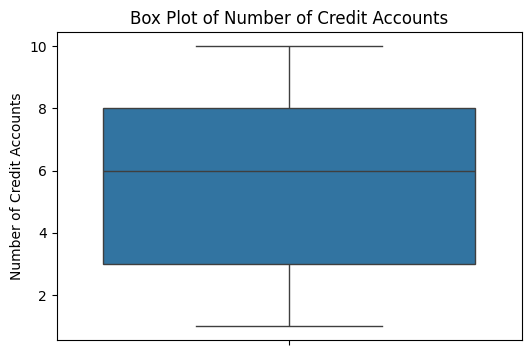

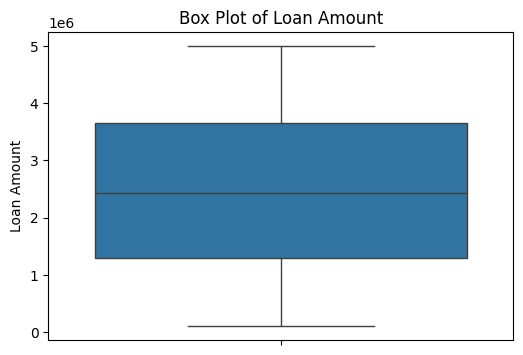

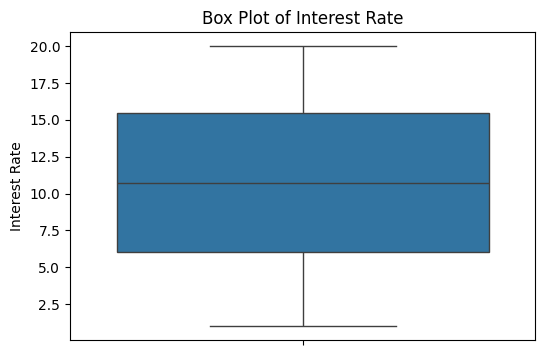

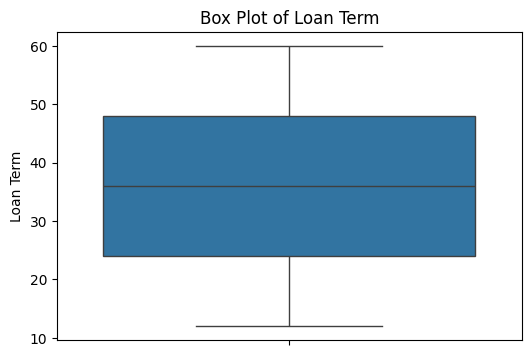

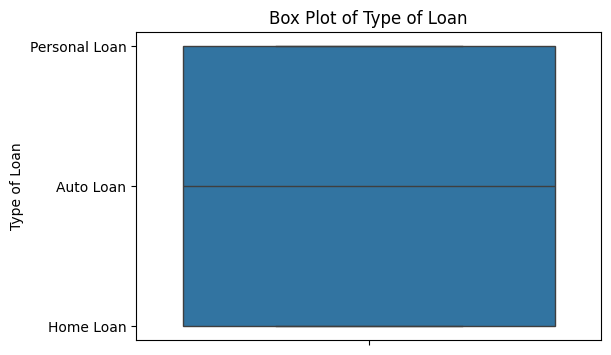

In [12]:
# Box plots for all columns
plt.figure(figsize=(14, 8))
sns.boxplot(data=dataset, palette='pastel')
plt.title('Box Plots of Features')
plt.xticks(rotation=45)
plt.show()


for col in dataset.columns:
    plt.figure(figsize=(6, 4))
    sns.boxplot(y=dataset[col])
    plt.title(f'Box Plot of {col}')
    plt.show()


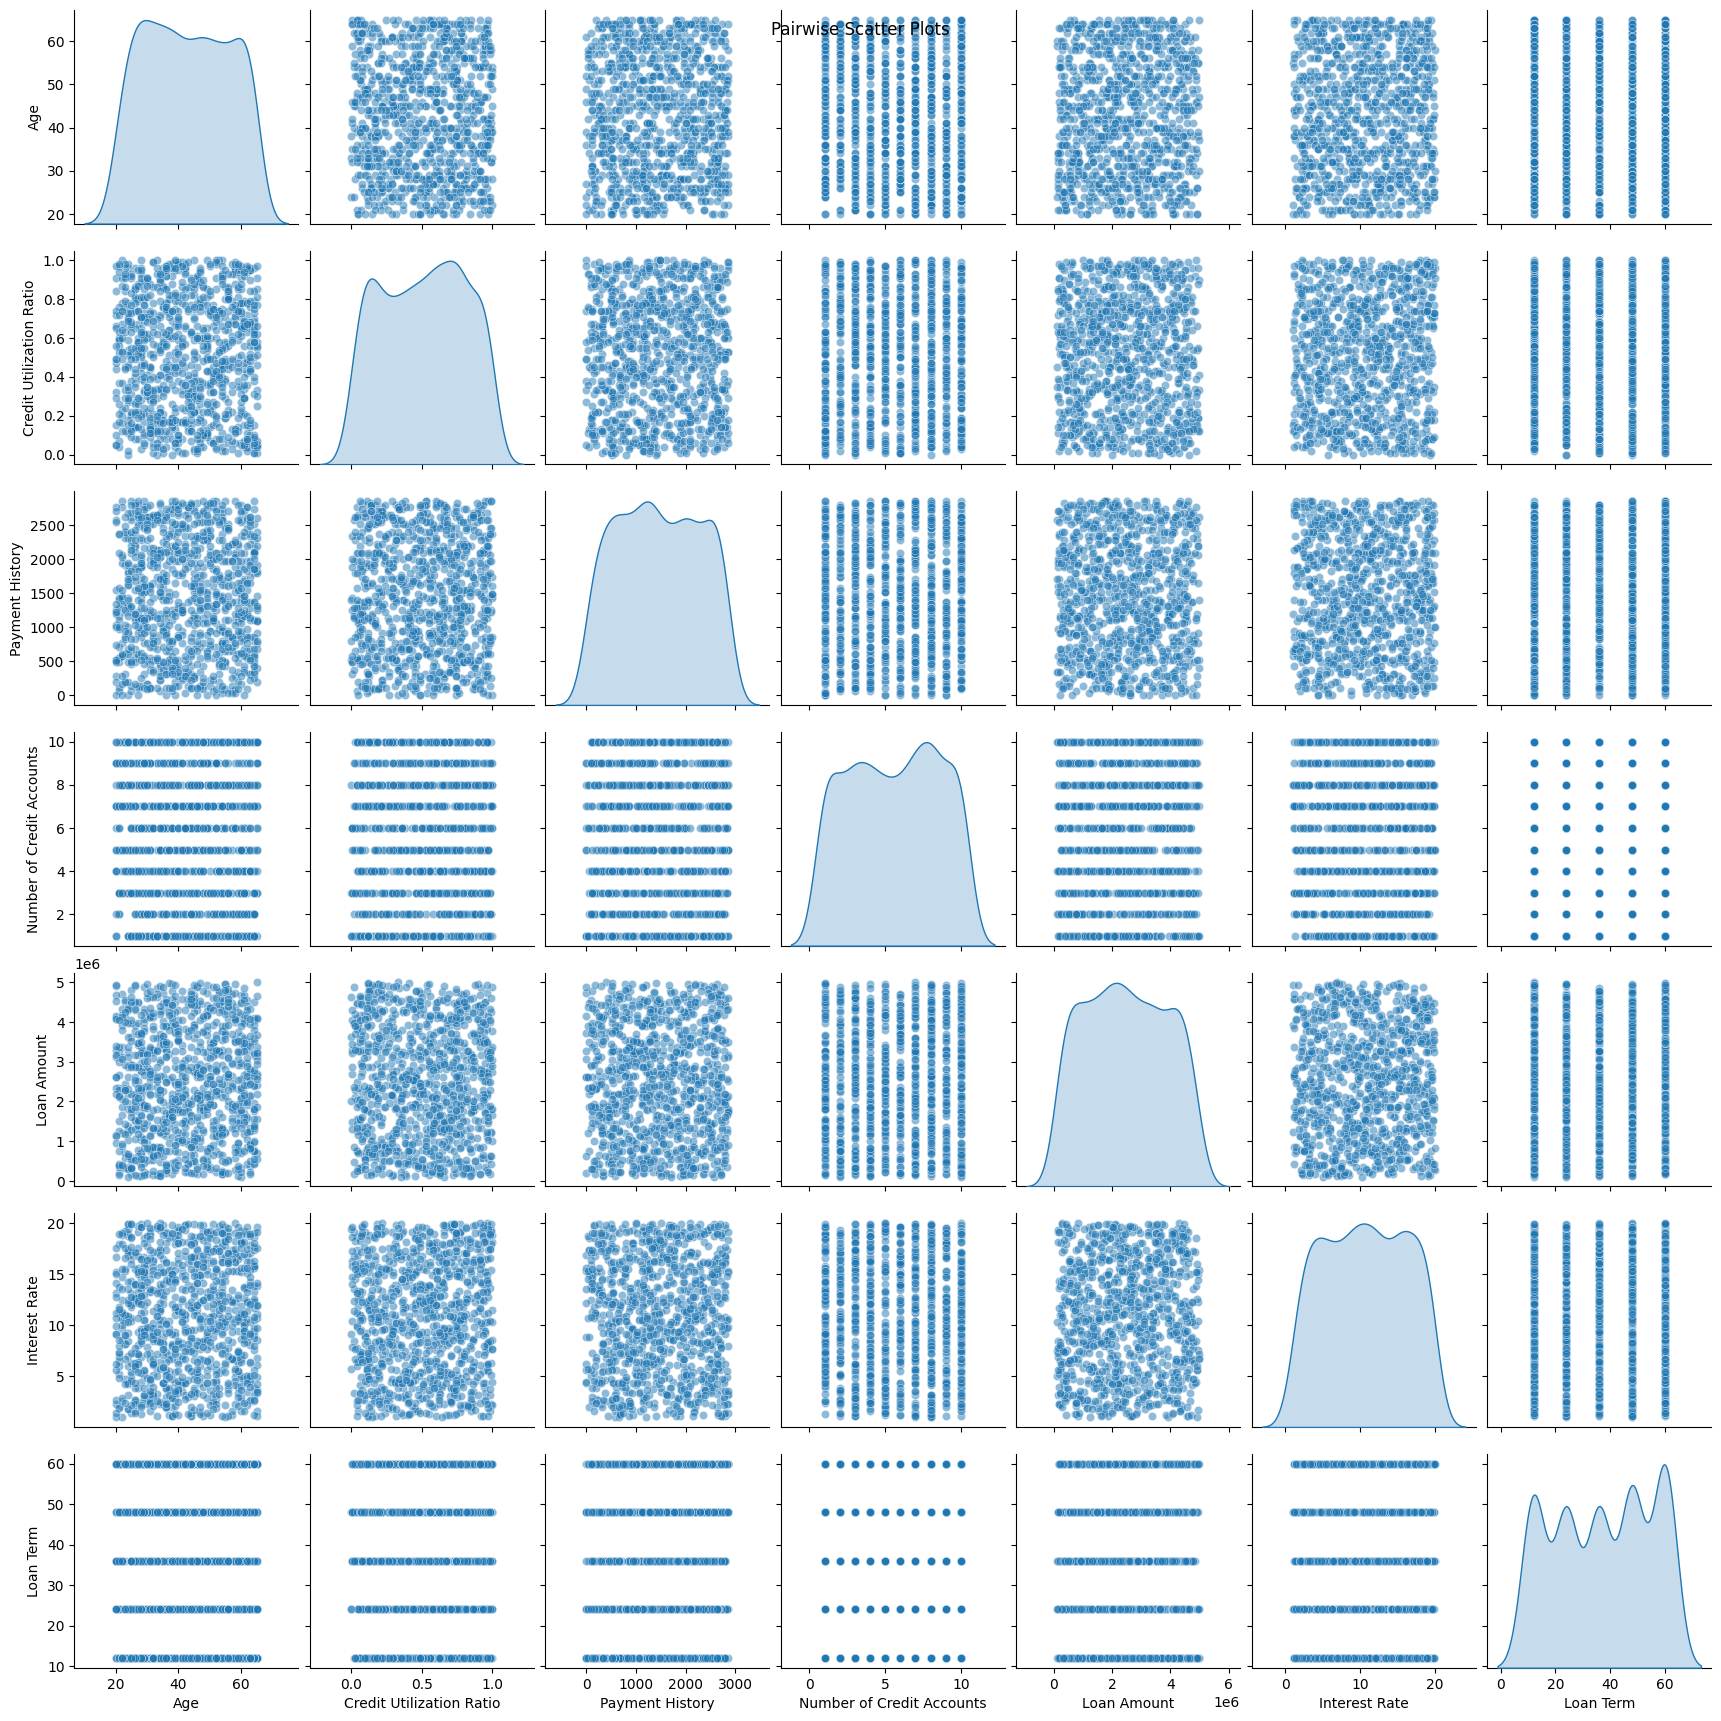

In [13]:
# Pairplot for relationships (subset if too many columns)
sns.pairplot(dataset, diag_kind='kde', plot_kws={'alpha': 0.5})
plt.suptitle('Pairwise Scatter Plots')
plt.show()

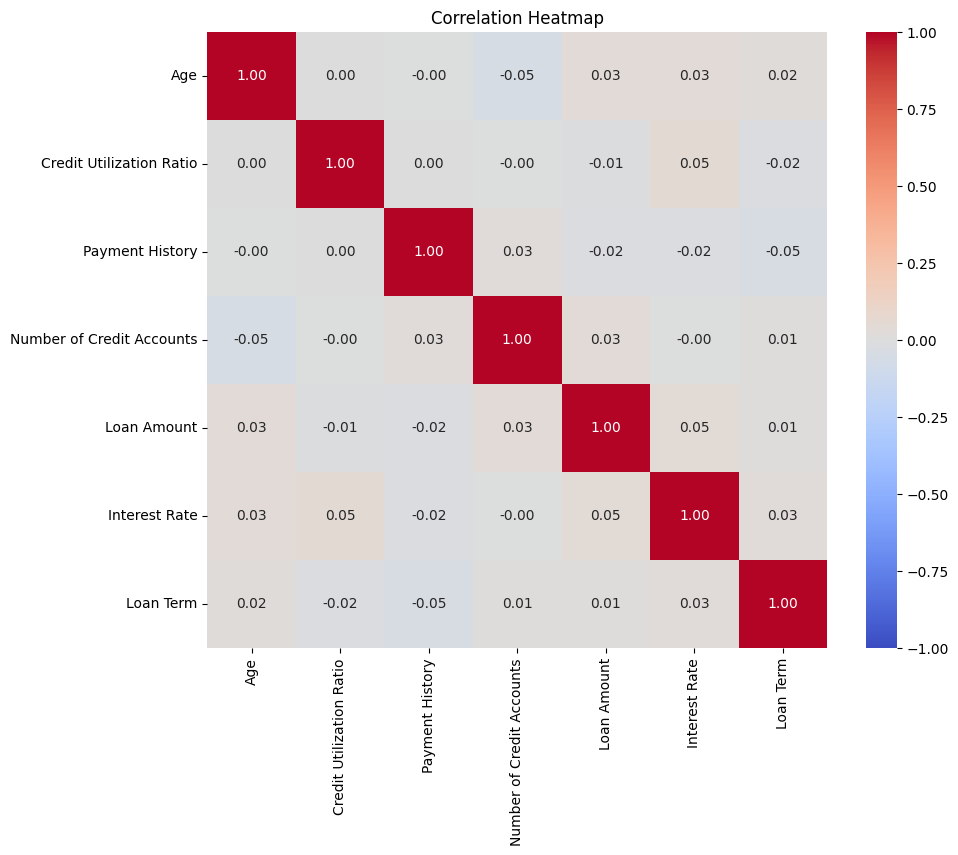

                                Age  Credit Utilization Ratio  \
Age                        1.000000                  0.001308   
Credit Utilization Ratio   0.001308                  1.000000   
Payment History           -0.003114                  0.002114   
Number of Credit Accounts -0.050672                 -0.001842   
Loan Amount                0.034114                 -0.014918   
Interest Rate              0.032867                  0.048237   
Loan Term                  0.021395                 -0.022924   

                           Payment History  Number of Credit Accounts  \
Age                              -0.003114                  -0.050672   
Credit Utilization Ratio          0.002114                  -0.001842   
Payment History                   1.000000                   0.025022   
Number of Credit Accounts         0.025022                   1.000000   
Loan Amount                      -0.019084                   0.032232   
Interest Rate                    -0.01761

In [14]:
# Compute correlation matrix
corr_matrix = dataset.corr(numeric_only=True)

# Heatmap visualization
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt=".2f")
plt.title('Correlation Heatmap')
plt.show()

# Print the matrix for text reference
print(corr_matrix)

In [15]:
from sklearn.preprocessing import LabelEncoder

if 'Gender' in dataset.columns:
    le = LabelEncoder()
    dataset['Gender'] = le.fit_transform(dataset['Gender'])

categorical_cols = dataset.select_dtypes(include=['object', 'category']).columns.tolist()

if categorical_cols:
    dataset_encoded = pd.get_dummies(dataset, columns=categorical_cols, drop_first=True)
    print("Encoded all categorical columns:", categorical_cols)
    print("Encoded dataset preview:")
    print(dataset_encoded.head())
    print("\nNew columns after encoding:", list(dataset_encoded.columns))
else:
    dataset_encoded = dataset.copy()
    print("No categorical columns found; no encoding applied.")



Encoded all categorical columns: ['Marital Status', 'Education Level', 'Employment Status', 'Type of Loan']
Encoded dataset preview:
   Age  Gender  Credit Utilization Ratio  Payment History  \
0   60       1                      0.22           2685.0   
1   25       1                      0.20           2371.0   
2   30       0                      0.22           2771.0   
3   58       0                      0.12           1371.0   
4   32       1                      0.99            828.0   

   Number of Credit Accounts  Loan Amount  Interest Rate  Loan Term  \
0                          2      4675000           2.65         48   
1                          9      3619000           5.19         60   
2                          6       957000           2.76         12   
3                          2      4731000           6.57         60   
4                          2      3289000           6.28         36   

   Marital Status_Married  Marital Status_Single  Education Level_High Sc

In [17]:
skewness = dataset_encoded.skew()
kurtosis = dataset_encoded.kurt()
print("Skewness:\n", skewness)
print("Kurtosis:\n", kurtosis)

Skewness:
 Age                                0.037307
Gender                            -0.004006
Credit Utilization Ratio          -0.047891
Payment History                    0.008305
Number of Credit Accounts         -0.052239
Loan Amount                        0.040701
Interest Rate                     -0.020069
Loan Term                         -0.095345
Marital Status_Married             0.629916
Marital Status_Single              0.753267
Education Level_High School        1.156436
Education Level_Master             1.084127
Education Level_PhD                1.187588
Employment Status_Self-Employed    0.643802
Employment Status_Unemployed       0.748388
Type of Loan_Home Loan             0.733819
Type of Loan_Personal Loan         0.753267
dtype: float64
Kurtosis:
 Age                               -1.217513
Gender                            -2.003996
Credit Utilization Ratio          -1.203143
Payment History                   -1.184178
Number of Credit Accounts         -1.25

In [18]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
import xgboost as xgb
import pandas as pd

In [19]:
# Assuming 'Interest_Rate' as target (adjust if another column is intended)
X = dataset_encoded.drop('Interest Rate', axis=1)  # Features
y = dataset_encoded['Interest Rate']  # Target

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Training set shape: {X_train.shape}")
print(f"Test set shape: {X_test.shape}")

Training set shape: (800, 16)
Test set shape: (200, 16)


In [20]:
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)
lr_pred = lr_model.predict(X_test_scaled)

lr_mse = mean_squared_error(y_test, lr_pred)
lr_r2 = r2_score(y_test, lr_pred)
print(f"Linear Regression - MSE: {lr_mse:.4f}, R²: {lr_r2:.4f}")

Linear Regression - MSE: 31.7109, R²: -0.0108


In [21]:
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train_scaled, y_train)
rf_pred = rf_model.predict(X_test_scaled)

rf_mse = mean_squared_error(y_test, rf_pred)
rf_r2 = r2_score(y_test, rf_pred)
print(f"Random Forest - MSE: {rf_mse:.4f}, R²: {rf_r2:.4f}")

Random Forest - MSE: 33.6138, R²: -0.0714


In [22]:
xgb_model = xgb.XGBRegressor(objective='reg:squarederror', n_estimators=100, random_state=42)
xgb_model.fit(X_train_scaled, y_train)
xgb_pred = xgb_model.predict(X_test_scaled)

xgb_mse = mean_squared_error(y_test, xgb_pred)
xgb_r2 = r2_score(y_test, xgb_pred)
print(f"XGBoost - MSE: {xgb_mse:.4f}, R²: {xgb_r2:.4f}")

XGBoost - MSE: 42.1636, R²: -0.3440


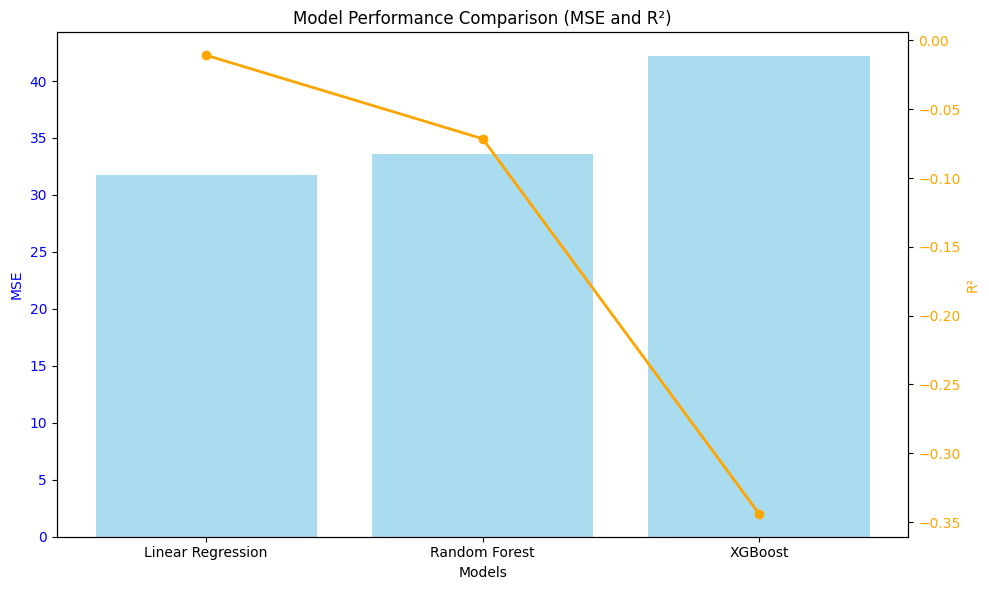

In [23]:
models = ['Linear Regression', 'Random Forest', 'XGBoost']
mses = [lr_mse, rf_mse, xgb_mse]
r2s = [lr_r2, rf_r2, xgb_r2]

fig, ax1 = plt.subplots(figsize=(10, 6))

# Bar for MSE
ax1.bar(models, mses, color='skyblue', alpha=0.7, label='MSE')
ax1.set_xlabel('Models')
ax1.set_ylabel('MSE', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')

# Twin axis for R²
ax2 = ax1.twinx()
ax2.plot(models, r2s, color='orange', marker='o', linewidth=2, label='R²')
ax2.set_ylabel('R²', color='orange')
ax2.tick_params(axis='y', labelcolor='orange')

plt.title('Model Performance Comparison (MSE and R²)')
fig.tight_layout()
plt.show()

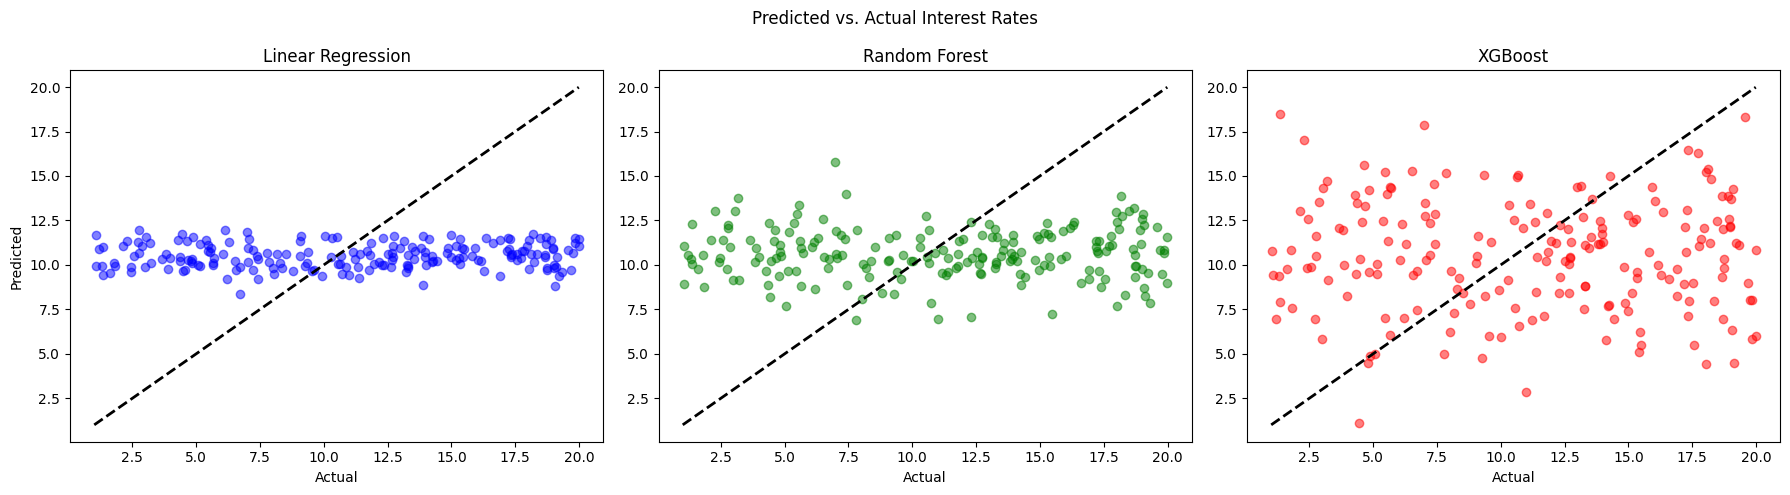

In [24]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Predicted vs. Actual Interest Rates')

# Linear Regression
axes[0].scatter(y_test, lr_pred, alpha=0.5, color='blue')
axes[0].plot([y.min(), y.max()], [y.min(), y.max()], 'k--', lw=2)
axes[0].set_xlabel('Actual')
axes[0].set_ylabel('Predicted')
axes[0].set_title('Linear Regression')

# Random Forest
axes[1].scatter(y_test, rf_pred, alpha=0.5, color='green')
axes[1].plot([y.min(), y.max()], [y.min(), y.max()], 'k--', lw=2)
axes[1].set_xlabel('Actual')
axes[1].set_title('Random Forest')

# XGBoost
axes[2].scatter(y_test, xgb_pred, alpha=0.5, color='red')
axes[2].plot([y.min(), y.max()], [y.min(), y.max()], 'k--', lw=2)
axes[2].set_xlabel('Actual')
axes[2].set_title('XGBoost')

plt.tight_layout()
plt.show()

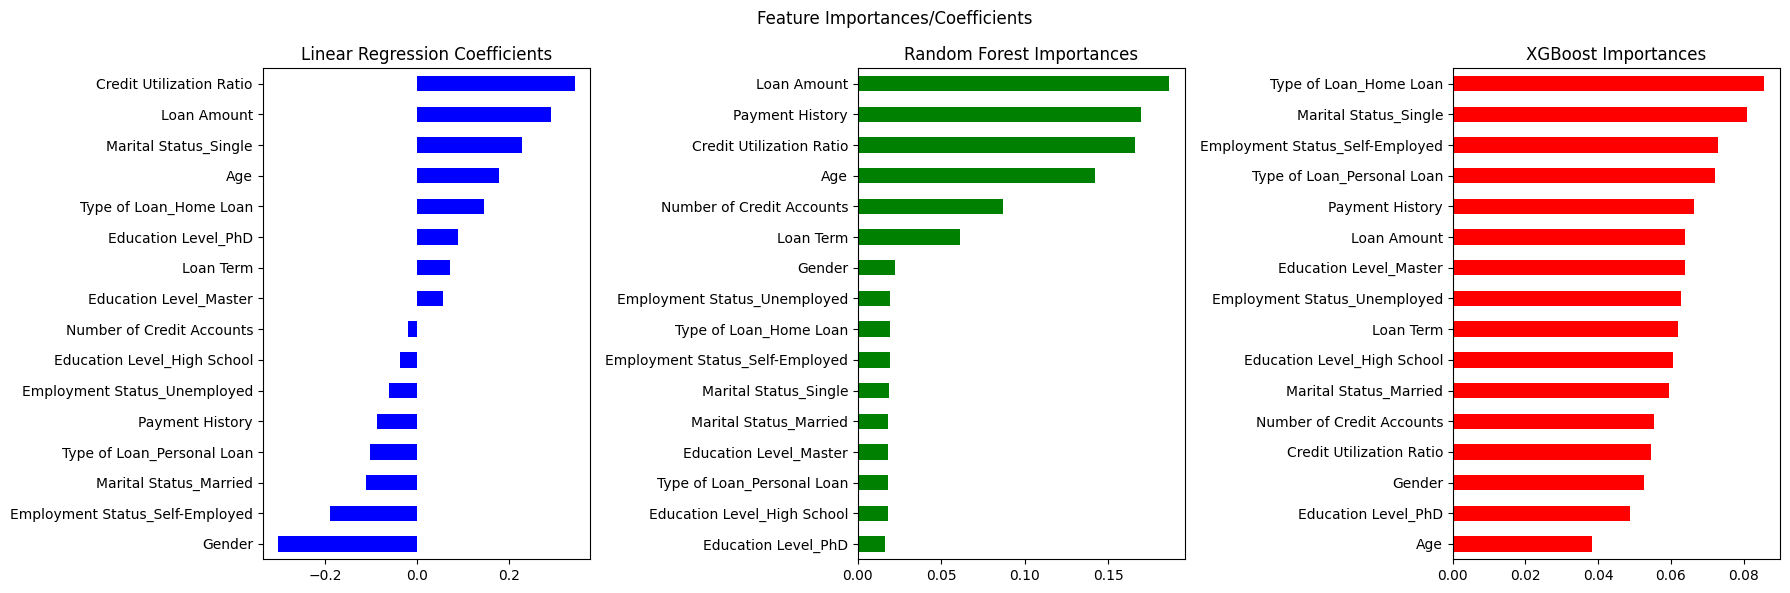

In [25]:
# Get importances
lr_coefs = pd.Series(lr_model.coef_, index=X.columns).sort_values()
rf_importances = pd.Series(rf_model.feature_importances_, index=X.columns).sort_values()
xgb_importances = pd.Series(xgb_model.feature_importances_, index=X.columns).sort_values()

# Plot
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Feature Importances/Coefficients')

# Linear Regression (coefficients)
lr_coefs.plot(kind='barh', ax=axes[0], color='blue')
axes[0].set_title('Linear Regression Coefficients')

# Random Forest
rf_importances.plot(kind='barh', ax=axes[1], color='green')
axes[1].set_title('Random Forest Importances')

# XGBoost
xgb_importances.plot(kind='barh', ax=axes[2], color='red')
axes[2].set_title('XGBoost Importances')

plt.tight_layout()
plt.show()

In [27]:
results = pd.DataFrame({
    'Model': models,
    'MSE': mses,
    'R²': r2s
})
print(results)

               Model        MSE        R²
0  Linear Regression  31.710944 -0.010779
1      Random Forest  33.613820 -0.071433
2            XGBoost  42.163641 -0.343956


In [28]:
import shap  # For SHAP explanations
# For LIME (install if needed: !pip install lime)
try:
    import lime
    import lime.lime_tabular
    print("LIME is imported successfully.")
except ImportError:
    !pip install lime
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 3.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=283834 sha256=44b79551dde02d3aa1f1c4cde78c87b286a49adf714311f471438e23b0cda4a2
  Stored in directory: /root/.cache/pip/wheels/e7/5d/0e/4b4fff9a47468fed5633211fb3b76d1db43fe806a17fb7486a
Successfully built lime


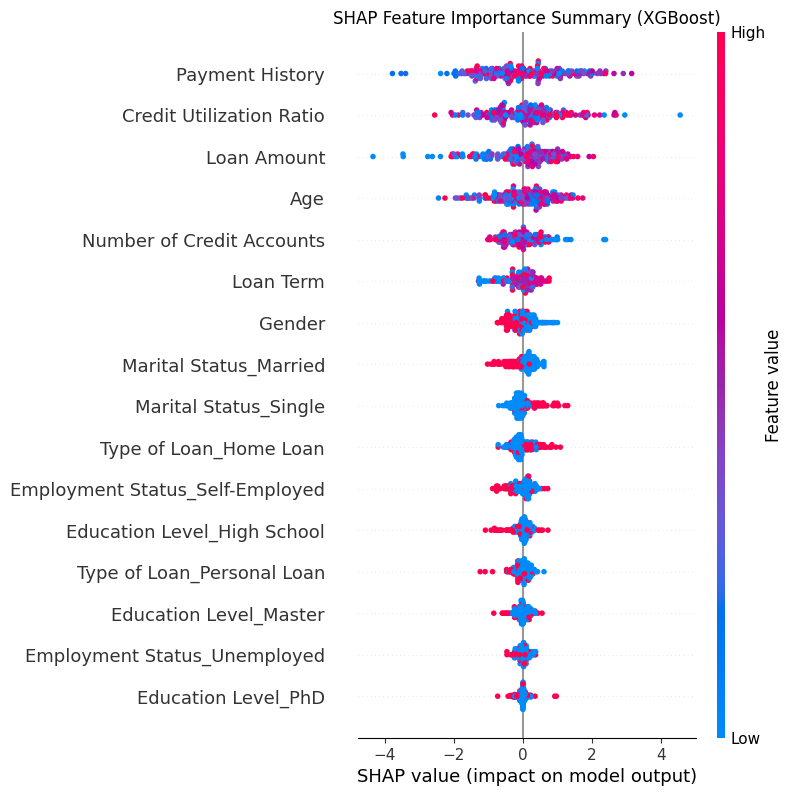

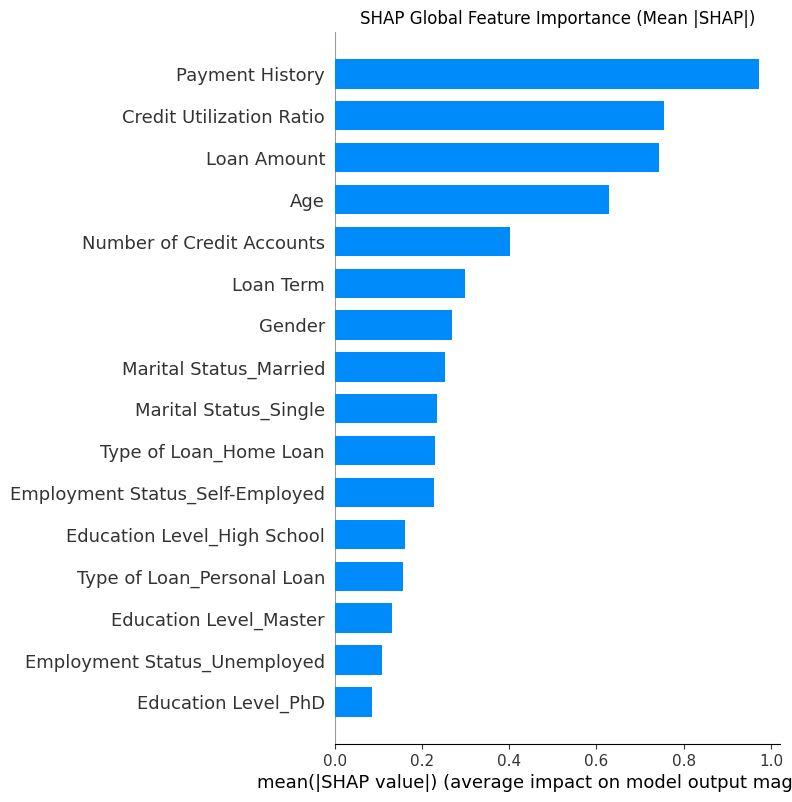

In [29]:
# Initialize SHAP explainer for XGBoost (or replace with rf_model for Random Forest)
explainer = shap.TreeExplainer(xgb_model)

# Compute SHAP values for the test set
shap_values = explainer.shap_values(X_test_scaled)

# Summary plot (beeswarm)
shap.summary_plot(shap_values, X_test_scaled, feature_names=X.columns, show=False)
plt.title('SHAP Feature Importance Summary (XGBoost)')
plt.show()

# Bar plot for mean absolute SHAP values (global importance)
shap.summary_plot(shap_values, X_test_scaled, plot_type="bar", feature_names=X.columns, show=False)
plt.title('SHAP Global Feature Importance (Mean |SHAP|)')
plt.show()

In [30]:
# Select an instance (e.g., first row of test set)

instance = X_test_scaled[0].reshape(1, -1)

# Get SHAP values for this instance
shap_values_instance = explainer.shap_values(instance)

# Force plot for visualization
shap.initjs()  # For Jupyter display
shap.force_plot(explainer.expected_value, shap_values_instance, instance, feature_names=X.columns)

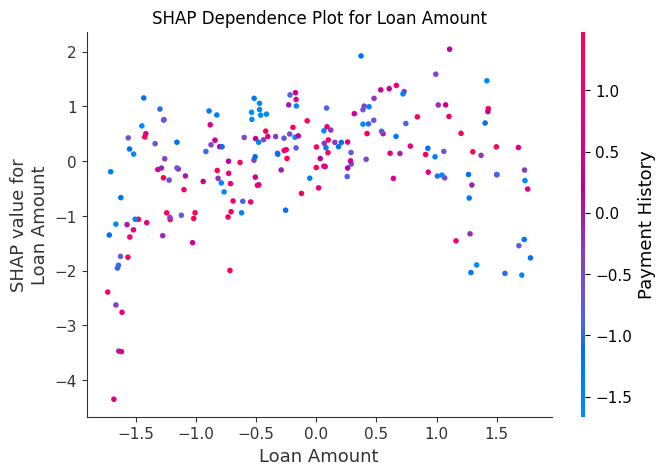

In [31]:
# Example: Dependence plot for 'Loan Amount'
shap.dependence_plot('Loan Amount', shap_values, pd.DataFrame(X_test_scaled, columns=X.columns), interaction_index='auto', show=False)
plt.title('SHAP Dependence Plot for Loan Amount')
plt.show()

## Credit Score Modelling



This project models financial distress provided a dataset on the problem